# Multilayer perceptron (MLP)

## n-gram model
We built a [character-level bigram](https://n03an.me/gpt/01_Bigram.html) model trained on a dataset of 32,000 names. Lets build a n-gram model using similar appraoch where n=4 i.e. 4-gram model.

### Shape of Input, Output and Weights
instead of single-character context, we will use 3-character sequence as input context and the next character as output. 

For the word "cat", the padded sequence is [".", "c", "a", "t", "."]. The 4-gram contexts and targets become:
* ["c", "a", "t"] → "."

* [".", "c", "a"] → "t"

... 😤 some grunt work...

In [19]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [20]:
# Build stoi and itos

chars = sorted(list(set(''.join(words))))
# s (str) to i (index)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# rever the array
itos = {i:s for s,i in stoi.items()}

print(f"stoi['a'] = {stoi['a']}")
print(f"itos[1] = {itos[1]}")

stoi['a'] = 1
itos[1] = a


#### Input
In case of bigram character model, we used the index of character in the vocabulary as input. In case of 4-gram model, we will need to convert the sequence of 3 characters into a single distinct integer.

i.e. There are **19,683 unique contexts** i.e. $27^3 = 19,683$.

🧮 Converting the 3-character context into a single integer is done by treating the 3 characters as a base-27 number.

$$
\boxed{
\text{ID} = \text{index}(c_0) \cdot 27^2 + \text{index}(c_1) \cdot 27 + \text{index}(c_2)
}
$$

where $c_0$, $c_1$, and $c_2$ are the three characters in the context. The index of each character is its position in the vocabulary (of size 27), including a special padding character (".") at index 0.



In [21]:
# 1. Create the dataset: map 3-character sequences to unique IDs
xs, ys = [], []
for w in ["emma"]:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        print(f'----sample {i+1} ----------------------')
        context = chs[i:i+3]  # 3-character window
        print(f'input sequence: {context}')
        target = chs[i+3]
        print(f'expected output: {target}')
        # Convert context to a unique integer (0 to 27³-1)
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        print(f'unique number for {context} sequence: {ix_context}')
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of samples in "emma":', num)

----sample 1 ----------------------
input sequence: ['.', 'e', 'm']
expected output: m
unique number for ['.', 'e', 'm'] sequence: 148
----sample 2 ----------------------
input sequence: ['e', 'm', 'm']
expected output: a
unique number for ['e', 'm', 'm'] sequence: 4009
----sample 3 ----------------------
input sequence: ['m', 'm', 'a']
expected output: .
unique number for ['m', 'm', 'a'] sequence: 9829
number of samples in "emma": 3


- The first character (context[0]) is the most significant digit, so it's multiplied by 27 squared (27^2). 
- The second character (context[1]) is multiplied by 27^1
- The third character (context[2]) is multiplied by 27^0, which is 1. 
Adding these products together gives a unique integer for every unique combination of the three characters. This ensures every possible 3-character combination gets a **unique integer ID** between 0 and \(27^3 - 1 = 19,682\).

> 💡 For example, if the characters are 'a', 'b', 'c' with indices 1, 2, 3 respectively, the calculation would be $$1 \cdot 27^2 + 2 \cdot 27^1 + 3 \cdot 1 = 729 + 54 + 3 = 786$$

**One-hot encoding**: with the total sequence size of 19683, the input to the model will be a one-hot vector of size Nx19683, where N is the batch size from the dataset. From our 32k names dataset, we can fetch total of 164080 3-char name sequences...

```python
xenc = F.one_hot(xs, num_classes=27**3).float()  # Shape [164080, 19683]
```
Note: each entry in `xs` represents a unique hash value for a 3-character sequence. The maxium value possible is 19682 for something like "zzz" and minimum is 0 for something like "...". So if the one hot vector row is representing `4009` for `emm` then  the 4009th index will be set to 1 and rest will be 0.


**Output**: The output will be a probability distribution of size 27 for each input in the batch of size N.

**Weights**: The weights will be a matrix of size (19683, 27). This means that each unique combination of 3 characters (row) will have a corresponding weight vector (27 columns) for each character in the vocabulary. (this is similar to how we were maintaining counts of character pairs in the bigram model).

```python
W = torch.randn((27**3, 27), generator=g, requires_grad=True)  # Shape [19683, 27]
```

In [40]:

xenc = F.one_hot(xs, num_classes=27**3).float()
print(f'input samples "xs" from emma : {xs}')
print('Shape of One Hot vector [Samples x Vocab Size]:', xenc.shape)
print(f'One hot vector for the first sample {xs[0]}:', xenc[0])

input samples "xs" from emma : tensor([ 148, 4009, 9829])
Shape of One Hot vector [Samples x Vocab Size]: torch.Size([3, 19683])
One hot vector for the first sample 148: tensor([0., 0., 0.,  ..., 0., 0., 0.])


basically the bit at position 148 would be 1, where rest 19682 entries would be 0

**Representing one hot encoding with 19683 into 3D - just for fun**

Sequence Indices: [ 4351  1960 14756 10856  7538  3890 12856  8088  1870 13924]
One-Hot Shape: (10, 19683)


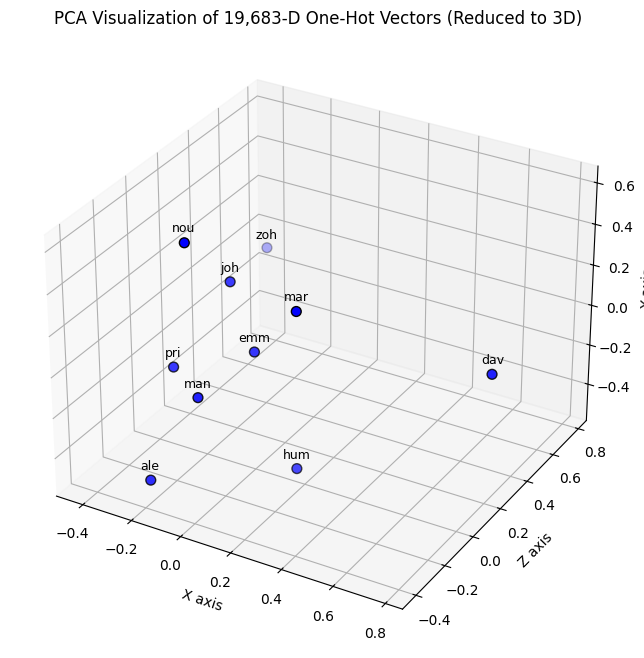

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting toolkit


charseq = ['emm', 'joh', 'mar', 'zoh', 'pri', 'hum', 'dav', 'ale', 'nou', 'man']
# generate 10 random integers within 19683 for representational purpose
indices = np.random.randint(0, 19683, size=10)  # Replace with your actual data
print("Sequence Indices:", indices)

# One-hot encode the sequences (shape: 10 x 19683)
one_hot_vectors = to_categorical(indices, num_classes=19683)
print("One-Hot Shape:", one_hot_vectors.shape)  # Output: (10, 19683)

# Reduce dimensionality to 3D using PCA
pca = PCA(n_components=3)
reduced_vectors = pca.fit_transform(one_hot_vectors)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points in 3D
scatter = ax.scatter(
    reduced_vectors[:, 0],  # PCA Component 1 (X-axis)
    reduced_vectors[:, 1],  # PCA Component 2 (Y-axis)
    reduced_vectors[:, 2],  # PCA Component 3 (Z-axis)
    c='blue', 
    edgecolor='k',
    s=50  # Marker size
)

# Annotate points with their original indices
for i, idx in enumerate(charseq):
    ax.text(
        reduced_vectors[i, 0], 
        reduced_vectors[i, 1], 
        reduced_vectors[i, 2] + 0.1, 
        str(idx), 
        fontsize=9,
        ha='center', 
        va='top'
    )

# Add labels and title
ax.set_title("PCA Visualization of 19,683-D One-Hot Vectors (Reduced to 3D)")
ax.set_xlabel("X axis")
ax.set_ylabel("Z axis")
ax.set_zlabel("Y axis")

plt.show()

#### Training the 4-gram model on 32k names dataset

In [22]:
import time

xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        context = chs[i:i+3]  
        target = chs[i+3]
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(xs.unique().shape)
print('number of samples in extracted from names dataset :', num)

# 2. Initialize weights for 19,683 possible contexts
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27**3, 27), generator=g, requires_grad=True)  # Shape [19683, 27]

def train(n, iteration):
    for k in range(n):
        start_time = time.time()
        # forward pass
        xenc = F.one_hot(xs, num_classes=27**3).float()  # Shape [164080, 19683]
        logits = xenc @ W  # Shape [164080, 27]
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
        
        # Backward pass and update
        W.grad = None
        loss.backward()

        # Update weights
        W.data += -50 * W.grad

        end_time = time.time()
        print(f'iteration {k+1} took {end_time - start_time:.2f} seconds')
    
    print(f'loss = {loss.item()} after training set {iteration}')

# Too slow
train(10, 1)
# train(100, 2)
# train(100, 3)
# train(100, 4)
# train(100, 5)

torch.Size([5659])
number of samples in extracted from names dataset : 164080
iteration 1 took 8.68 seconds
iteration 2 took 8.25 seconds
iteration 3 took 8.68 seconds
iteration 4 took 8.85 seconds
iteration 5 took 9.07 seconds
iteration 6 took 8.08 seconds
iteration 7 took 8.74 seconds
iteration 8 took 8.59 seconds
iteration 9 took 8.49 seconds
iteration 10 took 8.56 seconds
loss = 3.596501350402832 after training set 1


#### Generate Names

In [23]:
for i in range(10):
  
  out = []
  samples = 0
  while True:
    xenc = F.one_hot(torch.tensor([samples]), num_classes=27**3).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    samples = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[samples])
    if samples == 0:
      break
  print(''.join(out))

ozaltiygkbvmfhsy.
pbogmup.
rajqxedbvbuzwdbterdkriirejkmc.
pxjszwtognw.
phwmklecvogwptjw.
oqr.
trzikluuiqtgkpjluipalrh.
zsvwiisxlppohufpblvkhwdwmywpajwkkgkfuyu.
gdctktprqoafyypcccnabmunvloc.
fpjqbwrfbmalpbcjqxjmxc.


In [55]:
print('Total number of samples from names dataset :', num)
print(f'Unique 3 character sequence: {xs.unique().nelement()}')
print(f'No of unique sequences model have not seen: {num - xs.unique().nelement()}')

Total number of samples from names dataset : 164080
Unique 3 character sequence: 5659
No of unique sequences model have not seen: 158421


With a dataset of 32,000 names, we could barely generate 5659 unique sequence or tokens. Which means that the model have yet to learn on the remainder of 158421 possible sequences.

#### 🤷‍♂️ Hold on Jonny [read as n03an] 
- The model seems very slow
- We could only produce 5659 unique names from 32k names dataset
- the output is as rubbish as the bigram model

**Challenges**

1. **Sparsity and Memory Overhead**:
   - **One-Hot Encoding**: We can think of the 19,683 3-character sequences as **categorical features** — or one-hot encoded where each sample is a **sparse vector with 19,683 dimensions** (only one element is `1`, the rest are `0`). Storing 164,080 sparse vectors in memory as dense arrays is highly inefficient for what we are trying to achieve.
   - **Weight Matrix**: The weight matrix `(19683x27)` contains $(19683 \times 27 = 531,441)$ parameters. Thats again huge for tiny model.

2. **Generalization**:
   - **Rare 3-gram Sequences**: Many of the 19,683 possible 3-character sequences will appear infrequently (or not at all) in the training data. The model will fail to learn meaningful patterns for rare sequences, leading to poor generalization. In our case we could only generate 5659 unique names from 32k names dataset.

3. **Computational Cost**:
   - Matrix operations on large one-hot encoded inputs (e.g., multiplying `164080x19683` with `19683x27`) are computationally expensive.

## The Curse of Dimensionality [🚧 WIP]
🚧 TODO 🐫🔍 Study and implement the paper from Bengio
The paper by Bengio et al. (2003), "[*A Neural Probabilistic Language Model*](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)"

A goal of statistical language modeling is to learn the joint probability function of sequences of words _[or characters or tokens]_ in a language. This is difficult because a word sequence on which the model is trained may be very different from the word sequence on which the model is tested. This is called the _curse of dimensionality_. The curse of dimensionality refers to the fact that as the number of features (or dimensions) increases, the amount of data needed to estimate the joint probability function grows exponentially. This makes it difficult to learn a good model from limited data.


---

Given for such a large dimension / features of size 19,683 - most sequence will never appear in training data (making it sparse) and the model cannot generalize to unseen sequences (e.g., "xyz").

Language models predict the probability of the next word given previous words. For example:  
> *"The cat sat on the ___."*  
A model must predict "mat," "couch," etc.  

---

#### **The Problem**:  
- **Vocabulary size**: Suppose we have a vocabulary of 50,000 words.  
- **Sequence length**: If we model 10-word sequences, the number of possible combinations is \(50,000^{10}\)—a **high-dimensional discrete space**.  
- **Data sparsity**: Even with massive text corpora, most sequences will **never appear** in training data. For example, "*The purple refrigerator sang opera gracefully*" might never occur, making probability estimation impossible.  

This is the curse of dimensionality: the **exponential growth** of possible combinations in high-dimensional spaces makes learning statistically infeasible.

---

### **Example from the Paper**:  

1. **Learning distributed representations**:  
   - Instead of treating words as discrete "one-hot" vectors (e.g., 50,000 dimensions), words are mapped to **lower-dimensional embeddings** (e.g., 100-D).  
   - *Example*: Words like "cat" and "dog" have similar embeddings, capturing semantic relationships.  

2. **Sharing statistical strength**:  
   - Similar words share parameters in the embedding space. For example, if "*cat*" and "*kitten*" have similar embeddings, the model can generalize from "*The cat sat*" to "*The kitten sat*" without needing to see both phrases.  

3. **Avoiding exponential reliance on history**:  
   - Traditional n-gram models suffer because they explicitly model \(P(\text{word}_t | \text{word}_{t-1}, \dots, \text{word}_{t-n})\). For \(n=5\), this requires estimating probabilities for \(50,000^5\) combinations.  
   - Neural networks instead **compress** this information into dense vectors and nonlinear transformations, reducing dimensionality.